<a href="https://colab.research.google.com/github/tenandq-cmyk/ikinari-clinic/blob/master/COMET_Reel_Generator_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 COMET Reel Generator v3

**@comet_kosodate** 用 Instagram リール自動生成

---

| Step | 内容 |
|---|---|
| ⚙️ **初期設定** | ライブラリ・APIキー・エンジン読み込み |
| 📝 **ネタ入力** | YouTube URL or 文字起こし or 自分のネタを貼る |
| 🎨 **Agent 2** | 構成・MJプロンプト・Threads文・ハッシュタグ生成 |
| 🎙️ **Agent 2.5** | ナレーション音声生成 |
| 🎬 **動画生成** | MJ画像 → 動画化 |
| 📊 **Agent 3** | インサイト分析・改善レポート |

**ネタ探しは自分でやる。いい動画を見つけたらURLか文字起こしを貼るだけ。**

## ⚙️ Step 1: 初期設定（最初に1回だけ実行）

In [ ]:
# ライブラリのインストール
!pip install moviepy Pillow pytrends google-api-python-client youtube-transcript-api -q
!apt-get install -y -q fonts-noto-cjk

import os, json, re, datetime, requests

# 丸ゴシック（M PLUS Rounded 1c）をDL — リールで定番のぽってり系
import urllib.request, zipfile
_FONT_URL = 'https://fonts.google.com/download?family=M+PLUS+Rounded+1c'
_FONT_DIR = '/usr/share/fonts/mplus-rounded'
if not os.path.exists(_FONT_DIR):
    os.makedirs(_FONT_DIR, exist_ok=True)
    try:
        urllib.request.urlretrieve(_FONT_URL, '/tmp/mplus.zip')
        with zipfile.ZipFile('/tmp/mplus.zip', 'r') as z:
            z.extractall(_FONT_DIR)
        print('✅ M PLUS Rounded 1c フォント インストール完了')
    except Exception as e:
        print(f'⚠️ 丸ゴシックDL失敗（NotoSansCJKで続行）: {e}')

import numpy as np
from PIL import Image, ImageDraw, ImageFont
from moviepy.editor import VideoClip, concatenate_videoclips
from google.colab import drive

drive.mount('/content/drive')

OUTPUT_DIR  = '/content/drive/MyDrive/COMET_Reels'
HISTORY_DIR = '/content/drive/MyDrive/COMET_Reels/_history'
os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(HISTORY_DIR, exist_ok=True)

W, H, FPS = 1080, 1920, 30
COMET_ORANGE = '#FF8C5A'

print('✅ 初期設定完了！Step 2 に進んでください。')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.2/485.2 kB 14.4 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
Suggested packages:
  fonts-noto-cjk-extra
The following NEW packages will be installed:
  fonts-noto-cjk
0 upgraded, 1 newly installed, 0 to remove and 6 not upgraded.
Need to get 61.2 MB of archives.
After this operation, 93.2 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-noto-cjk all 1:20220127+repack1-1 [61.2 MB]
Fetched 61.2 MB in 3s (22.9 MB/s)
Selecting previously unselected package fonts-noto-cjk.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-noto-cjk_1%3a20220127+repack1-1_all.deb ...
Unpacking fonts-noto-cjk (1:20220127+repack1-1) ...
Setting up fonts-noto-cjk (1:20220127+repack1-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
⚠️ 丸ゴシックDL失敗（NotoSansCJKで続行）: File is not a zip file


/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



Mounted at /content/drive
✅ 初期設定完了！Step 2 に進んでください。


## 🔑 Step 2: APIキーの設定

- **Gemini**: [Google AI Studio](https://aistudio.google.com/app/apikey)
- **YouTube**: [Google Cloud Console](https://console.cloud.google.com/) → YouTube Data API v3 を有効化
- **Instagram**: 任意（空欄でも手動入力モードで動作します）

In [ ]:

from google.colab import userdata

def get_secret(key, fallback=''):
    try:
        return userdata.get(key)
    except:
        return fallback

# Colab Secrets から自動取得（未設定の場合は直接入力）
GEMINI_API_KEY         = get_secret('GEMINI_API_KEY')         or 'YOUR_GEMINI_API_KEY'
YOUTUBE_API_KEY        = get_secret('YOUTUBE_API_KEY')        or ''
INSTAGRAM_ACCESS_TOKEN = get_secret('INSTAGRAM_ACCESS_TOKEN') or ''

# ↓ 育児チャット誘導画像のパス（Google Drive上）
CTA_IMAGE_PATH = '/content/drive/MyDrive/COMET_Reels/cta.jpg'
# パスが分からない場合は以下を実行して確認：
# import os
# for root, dirs, files in os.walk('/content/drive/MyDrive'):
#     for f in files:
#         if f == 'cta.jpg':
#             print(os.path.join(root, f))

# ── 確認表示 ──
print('✅ APIキー設定完了！')
print(f'   Gemini       : {"✅ 設定済み" if GEMINI_API_KEY and GEMINI_API_KEY != "YOUR_GEMINI_API_KEY" else "❌ 未設定"}')
print(f'   YouTube      : {"✅ 設定済み" if YOUTUBE_API_KEY else "⚠️  未設定（pytrends のみで動作）"}')
print(f'   Instagram    : {"✅ 設定済み" if INSTAGRAM_ACCESS_TOKEN else "⚠️  未設定（手動入力モード）"}')
if not __import__('os').path.exists(CTA_IMAGE_PATH):
    print(f'   CTA画像      : ❌ 見つかりません → {CTA_IMAGE_PATH}')
else:
    print(f'   CTA画像      : ✅ 確認済み ({__import__("os").path.basename(CTA_IMAGE_PATH)})')


✅ APIキー設定完了！
   Gemini       : ✅ 設定済み
   YouTube      : ✅ 設定済み
   Instagram    : ⚠️  未設定（手動入力モード）
   CTA画像      : ✅ 確認済み (cta.jpg)


## 🛠️ エンジン読み込み（実行するだけ）

In [ ]:

# ============================================================
# 共通ユーティリティ
# ============================================================

def call_gemini(prompt, system_prompt=None, json_mode=False):
    url = f'https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent?key={GEMINI_API_KEY}'
    contents = []
    if system_prompt:
        contents.append({'role': 'user',  'parts': [{'text': system_prompt}]})
        contents.append({'role': 'model', 'parts': [{'text': 'はい、承知しました。'}]})
    contents.append({'role': 'user', 'parts': [{'text': prompt}]})
    body = {'contents': contents}
    if json_mode:
        body['generationConfig'] = {'responseMimeType': 'application/json'}
    r = requests.post(url, json=body, timeout=120)
    r.raise_for_status()
    return r.json()['candidates'][0]['content']['parts'][0]['text']

def extract_json(text):
    text = text.strip()
    if '```' in text:
        m = re.search(r'```(?:json)?\s*(.*?)```', text, re.DOTALL)
        if m: text = m.group(1).strip()
    s, e = text.find('{'), text.rfind('}')
    if s != -1 and e != -1: text = text[s:e+1]
    return json.loads(text)

# ============================================================
# 学習システム（全エージェント共通）
# ============================================================

LEARNING_PATH = os.path.join(HISTORY_DIR, '_learning.json')

LEARNING_DEFAULTS = {
    'updated_at': None,
    'total_posts': 0,
    'agent1': {
        'top_hook_types':    [],   # 高ER順のフック型
        'top_queries':       [],   # 成果の出た検索クエリ
        'avoid_topics':      [],   # 反応悪かったトピック傾向
        'insights':          '（まだデータなし）',
    },
    'agent2': {
        'hook_type_scores':  {},   # {'逆張り': 85, '数字': 78, ...}
        'content_insights':  '（まだデータなし）',
        'caption_insights':  '（まだデータなし）',
        'hashtag_insights':  '（まだデータなし）',
        'mj_prompt_insights':'（まだデータなし）',
    },
    'agent3': {
        'avg_er':            None,
        'avg_save_rate':     None,
        'avg_plays':         None,
        'benchmarks':        '（まだデータなし）',
        'pattern_insights':  '（まだデータなし）',
    },
}

def load_learnings():
    """学習データを読み込む。なければデフォルト値を返す"""
    if os.path.exists(LEARNING_PATH):
        with open(LEARNING_PATH, 'r', encoding='utf-8') as f:
            data = json.load(f)
        # 新しいキーがあればデフォルト値でマージ
        for section, defaults in LEARNING_DEFAULTS.items():
            if section not in data:
                data[section] = defaults
            elif isinstance(defaults, dict):
                for k, v in defaults.items():
                    if k not in data[section]:
                        data[section][k] = v
        return data
    return dict(LEARNING_DEFAULTS)

def update_learnings(new_learning: dict):
    """学習データを上書き保存"""
    new_learning['updated_at'] = datetime.datetime.now().isoformat()
    with open(LEARNING_PATH, 'w', encoding='utf-8') as f:
        json.dump(new_learning, f, ensure_ascii=False, indent=2)
    print(f'🧠 学習データ更新: {LEARNING_PATH}')
    return new_learning

def format_learnings_for_agent(learnings: dict, agent: str) -> str:
    """各エージェント向けに学習データを文字列に変換"""
    total = learnings.get('total_posts', 0)
    if total == 0:
        return '（学習データなし・初回実行）'

    a = learnings.get(agent, {})
    lines = [f'【過去{total}投稿からの学習データ】']

    if agent == 'agent1':
        if a.get('top_hook_types'):
            lines.append(f'・高ER フック型Top3: {", ".join(a["top_hook_types"][:3])}')
        if a.get('top_queries'):
            lines.append(f'・成果の出た検索クエリ: {", ".join(a["top_queries"][:3])}')
        if a.get('avoid_topics'):
            lines.append(f'・反応が悪かったトピック傾向: {", ".join(a["avoid_topics"][:2])}')
        lines.append(f'・総合知見: {a.get("insights", "-")}')

    elif agent == 'agent2':
        if a.get('hook_type_scores'):
            sorted_hooks = sorted(a['hook_type_scores'].items(), key=lambda x: x[1], reverse=True)
            lines.append(f'・フック型平均スコア: {" / ".join([f"{k}={v}" for k,v in sorted_hooks])}')
        lines.append(f'・コンテンツ知見: {a.get("content_insights", "-")}')
        lines.append(f'・キャプション知見: {a.get("caption_insights", "-")}')
        lines.append(f'・ハッシュタグ知見: {a.get("hashtag_insights", "-")}')
        lines.append(f'・MJプロンプト知見: {a.get("mj_prompt_insights", "-")}')

    elif agent == 'agent3':
        a3 = learnings.get('agent3', {})
        if a3.get('avg_er') is not None:
            lines.append(f'・過去平均ER: {a3["avg_er"]}% / 保存率: {a3["avg_save_rate"]}% / 再生数: {a3["avg_plays"]:,}')
        lines.append(f'・ベンチマーク: {a3.get("benchmarks", "-")}')
        lines.append(f'・パターン知見: {a3.get("pattern_insights", "-")}')

    return '\n'.join(lines)

# ============================================================
# フォント・画像・動画エンジン
# ============================================================

def get_font(size, bold=True):
    # 丸ゴシック優先 → NotoSansCJK fallback
    if bold:
        paths = [
            '/usr/share/fonts/mplus-rounded/MPLUSRounded1c-ExtraBold.ttf',
            '/usr/share/fonts/mplus-rounded/MPLUSRounded1c-Bold.ttf',
            '/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc',
            '/usr/share/fonts/truetype/noto/NotoSansCJK-Bold.ttc',
            '/usr/share/fonts/noto-cjk/NotoSansCJK-Bold.ttc',
        ]
    else:
        paths = [
            '/usr/share/fonts/mplus-rounded/MPLUSRounded1c-Medium.ttf',
            '/usr/share/fonts/mplus-rounded/MPLUSRounded1c-Regular.ttf',
            '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
            '/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc',
            '/usr/share/fonts/noto-cjk/NotoSansCJK-Regular.ttc',
        ]
    for p in paths:
        if os.path.exists(p):
            try: return ImageFont.truetype(p, size, index=0)
            except: continue
    return ImageFont.load_default()

def wrap_text_to_width(text, font, max_width, draw):
    result = []
    for line in text.split('\n'):
        bbox = draw.textbbox((0, 0), line, font=font)
        if bbox[2] - bbox[0] <= max_width or len(line) == 0:
            result.append(line)
        else:
            cur = ''
            for ch in line:
                test = cur + ch
                bbox = draw.textbbox((0, 0), test, font=font)
                if bbox[2] - bbox[0] > max_width and cur:
                    result.append(cur); cur = ch
                else:
                    cur = test
            if cur: result.append(cur)
    return result

def fit_image_to_frame(img_path):
    img = Image.open(img_path).convert('RGB')
    ow, oh = img.size
    scale = max(W / ow, H / oh)
    nw, nh = int(ow * scale), int(oh * scale)
    img = img.resize((nw, nh), Image.LANCZOS)
    l, t = (nw - W) // 2, (nh - H) // 2
    return img.crop((l, t, l + W, t + H))

def add_gradient_overlay(img, scene_type='tip'):
    img = img.convert('RGBA')
    overlay = Image.new('RGBA', (W, H), (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)
    if scene_type in ('cover', 'cta'):
        # 上下からグラデ（中央は画像が見える）
        for i in range(H // 3):
            a = int(160 * (1 - i / (H // 3)))
            draw.line([(0, i), (W, i)], fill=(0, 0, 0, a))
        for i in range(H // 3):
            a = int(180 * (i / (H // 3)))
            y = H - H // 3 + i
            draw.line([(0, y), (W, y)], fill=(0, 0, 0, a))
        # 全体に薄い暗幕
        draw.rectangle([0, 0, W, H], fill=(0, 0, 0, 60))
    else:
        # コンテンツ: 下半分からしっかりグラデ
        grad_start_y = int(H * 0.35)
        steps = H - grad_start_y
        for i in range(steps):
            alpha = int(220 * (i / steps) ** 1.3)
            draw.line([(0, grad_start_y + i), (W, grad_start_y + i)], fill=(0, 0, 0, min(alpha, 230)))
    return Image.alpha_composite(img, overlay)

def _draw_text_with_stroke(draw, xy, text, font, fill, stroke_width=4, stroke_fill=(0, 0, 0, 200)):
    """縁取り付きテキスト描画 — リール動画の定番スタイル"""
    draw.text(xy, text, font=font, fill=fill,
              stroke_width=stroke_width, stroke_fill=stroke_fill)

def _draw_text_with_bg(draw, xy, text, font, fill, bg_fill=(0, 0, 0, 100), pad_x=16, pad_y=8, radius=12):
    """半透明背景付きテキスト描画"""
    bbox = draw.textbbox(xy, text, font=font)
    bg_box = [bbox[0] - pad_x, bbox[1] - pad_y, bbox[2] + pad_x, bbox[3] + pad_y]
    draw.rounded_rectangle(bg_box, radius=radius, fill=bg_fill)
    draw.text(xy, text, font=font, fill=fill)

def render_text_overlay(scene, scene_type):
    canvas = Image.new('RGBA', (W, H), (0, 0, 0, 0))
    draw = ImageDraw.Draw(canvas)
    WHITE  = (255, 255, 255, 255)
    CREAM  = (255, 250, 240, 255)
    ORANGE = (255, 140, 90, 255)
    SHADOW = (0, 0, 0, 180)
    PAD    = 60

    if scene_type == 'cover':
        tf = get_font(88, True)
        sf = get_font(38, False)
        af = get_font(30, True)

        # main_text — 中央にデカく、縁取り
        tlines = wrap_text_to_width(scene.get('main_text', ''), tf, W - PAD * 2, draw)
        lh = tf.getbbox('あ')[3] + 24
        y = (H - lh * len(tlines)) // 2 - 80
        for ln in tlines:
            bbox = draw.textbbox((0, 0), ln, font=tf)
            x = (W - (bbox[2] - bbox[0])) // 2
            _draw_text_with_stroke(draw, (x, y), ln, tf, WHITE, stroke_width=5, stroke_fill=SHADOW)
            y += lh

        # sub_text — 半透明背景帯
        sub = scene.get('sub_text', '')
        if sub:
            y += 36
            for ln in wrap_text_to_width(sub, sf, W - PAD * 2, draw):
                bbox = draw.textbbox((0, 0), ln, font=sf)
                x = (W - (bbox[2] - bbox[0])) // 2
                _draw_text_with_bg(draw, (x, y), ln, sf, CREAM, bg_fill=(0, 0, 0, 90), pad_x=20, pad_y=10, radius=8)
                y += sf.getbbox('あ')[3] + 16

        # アカウント名
        acct = '@comet_kosodate'
        bbox = draw.textbbox((0, 0), acct, font=af)
        _draw_text_with_stroke(draw, (W - (bbox[2] - bbox[0]) - PAD, H - 90), acct, af, ORANGE, stroke_width=3, stroke_fill=(0, 0, 0, 150))

    elif scene_type not in ('cover', 'cta'):
        bf    = get_font(36, True)
        tf    = get_font(80, True)
        bodyf = get_font(40, False)
        af    = get_font(28, True)

        # ラベルバッジ（角丸・影付き）
        by = H - 580
        badge_text = scene.get('label', 'Point')
        bbox = draw.textbbox((0, 0), badge_text, font=bf)
        bw, bh = bbox[2] - bbox[0] + 48, bbox[3] - bbox[1] + 24
        # バッジ影
        draw.rounded_rectangle([PAD + 3, by + 3, PAD + bw + 3, by + bh + 3], radius=20, fill=(0, 0, 0, 80))
        draw.rounded_rectangle([PAD, by, PAD + bw, by + bh], radius=20, fill=ORANGE)
        draw.text((PAD + 24, by + 12), badge_text, font=bf, fill=WHITE)

        # main_text — 太く、縁取り
        y = by + bh + 32
        for ln in wrap_text_to_width(scene.get('main_text', ''), tf, W - PAD * 2, draw):
            _draw_text_with_stroke(draw, (PAD, y), ln, tf, WHITE, stroke_width=4, stroke_fill=SHADOW)
            y += tf.getbbox('あ')[3] + 16

        # body_text — やや小さく、半透明背景
        y += 16
        body = scene.get('body_text', '')
        if body:
            body_lines = wrap_text_to_width(body, bodyf, W - PAD * 2 - 32, draw)[:6]
            # 背景をまとめて描画
            blh = bodyf.getbbox('あ')[3] + 12
            total_h = blh * len(body_lines) + 24
            draw.rounded_rectangle([PAD - 8, y - 12, W - PAD + 8, y + total_h], radius=16, fill=(0, 0, 0, 100))
            for ln in body_lines:
                draw.text((PAD + 16, y), ln, font=bodyf, fill=CREAM)
                y += blh

        # アカウント名
        _draw_text_with_stroke(draw, (PAD, H - 80), '@comet_kosodate', af, ORANGE, stroke_width=2, stroke_fill=(0, 0, 0, 120))

    elif scene_type == 'cta':
        tf = get_font(80, True)
        sf = get_font(38, False)
        af = get_font(32, True)

        # main_text — 中央、縁取り
        tlines = wrap_text_to_width(scene.get('main_text', ''), tf, W - PAD * 2, draw)
        lh = tf.getbbox('あ')[3] + 24
        y = (H - lh * len(tlines)) // 2 - 80
        for ln in tlines:
            bbox = draw.textbbox((0, 0), ln, font=tf)
            x = (W - (bbox[2] - bbox[0])) // 2
            _draw_text_with_stroke(draw, (x, y), ln, tf, WHITE, stroke_width=5, stroke_fill=SHADOW)
            y += lh

        # sub_text
        sub = scene.get('sub_text', '')
        if sub:
            y += 36
            for ln in wrap_text_to_width(sub, sf, W - PAD * 2, draw):
                bbox = draw.textbbox((0, 0), ln, font=sf)
                x = (W - (bbox[2] - bbox[0])) // 2
                _draw_text_with_bg(draw, (x, y), ln, sf, CREAM, bg_fill=(0, 0, 0, 90), pad_x=20, pad_y=10, radius=8)
                y += sf.getbbox('あ')[3] + 16

        # アカウント名
        acct = '@comet_kosodate'
        bbox = draw.textbbox((0, 0), acct, font=af)
        _draw_text_with_stroke(draw, ((W - (bbox[2] - bbox[0])) // 2, H - 110), acct, af, ORANGE, stroke_width=3, stroke_fill=(0, 0, 0, 150))

    return canvas

def zoom_frame(base_np, t, duration, zoom_start=1.08, zoom_end=1.0):
    p     = min(t / duration, 1.0)
    scale = zoom_start + (zoom_end - zoom_start) * p
    nw, nh = int(W * scale), int(H * scale)
    img   = Image.fromarray(base_np.astype(np.uint8))
    img   = img.resize((nw, nh), Image.BILINEAR)
    l, t_ = (nw - W) // 2, (nh - H) // 2
    return np.array(img.crop((l, t_, l + W, t_ + H)), dtype=np.float32)

def make_animated_scene(img_path, scene, scene_type, duration=4.0):
    base_np  = np.array(add_gradient_overlay(fit_image_to_frame(img_path), scene_type).convert('RGB'), dtype=np.float32)
    text_np  = np.array(render_text_overlay(scene, scene_type), dtype=np.float32)
    text_a   = text_np[:, :, 3:4] / 255.0
    text_rgb = text_np[:, :, :3]
    static   = (base_np * (1 - text_a) + text_rgb * text_a).astype(np.uint8)

    if scene_type == 'cover':
        ZOOM_DUR, TEXT_FADE = duration, 0.6
        def make_frame(t):
            zoomed = zoom_frame(base_np, t, ZOOM_DUR, zoom_start=1.08, zoom_end=1.0)
            alpha  = min(t / TEXT_FADE, 1.0)
            eff    = text_a * alpha
            return (zoomed * (1 - eff) + text_rgb * eff).astype(np.uint8)
    else:
        def make_frame(t):
            if t >= 0.8: return static
            p = 1 - (1 - t / 0.8) ** 2
            offset = int(30 * (1 - p))
            if offset > 0:
                sa = np.zeros_like(text_a);   sa[offset:] = text_a[:H - offset]
                sr = np.zeros_like(text_rgb); sr[offset:] = text_rgb[:H - offset]
            else:
                sa, sr = text_a, text_rgb
            return (base_np * (1 - sa * p) + sr * sa * p).astype(np.uint8)

    return VideoClip(make_frame, duration=duration).set_fps(FPS)

print('✅ エンジン + 学習システム 読み込み完了！')

# 起動時に学習データのサマリーを表示
_init_learnings = load_learnings()
_total = _init_learnings.get('total_posts', 0)
if _total > 0:
    print(f'🧠 学習データ: 過去{_total}投稿分のデータあり（最終更新: {_init_learnings.get("updated_at","不明")[:10]}）')
else:
    print('🧠 学習データ: なし（初回実行）')


✅ エンジン + 学習システム 読み込み完了！
🧠 学習データ: なし（初回実行）


---
## 📝 ネタ入力

以下の **どれか1つ** を埋めて実行：
- **A. YouTube URL** → 自動で字幕取得
- **B. 文字起こし貼り付け** → URLなしでもOK（URL+文字起こしも可）
- **C. 自分のネタ** → YouTube不要、自由入力

In [ ]:
# ============================================================
# 📝 ネタ入力（A/B/C のどれかを埋める）
# ============================================================

# --- A. YouTube URLから自動取得 ---
VIDEO_URL = ''  # 例: 'https://youtube.com/watch?v=XXXXXXXXXXX'

# --- B. 文字起こしを直接貼り付け ---
TRANSCRIPT = """「【９割が知らない子育て厳選雑学】抱っこ魔ほど将来「ある」能力が高い」の内容を文字起こし・要約してまとめます。

この動画では、子供が抱っこを求める行動の科学的な意味と、それが将来どのような能力につながるのかが解説されています。

1. 抱っこを求める行動の本当の意味
子供が抱っこを求めるのは、単なる「甘え」や「わがまま」ではありません。

脳の未熟さを補う調整行動： 子供の脳はまだ不安や刺激を一人で処理できません。抱っこを求めることで、親の体温や心拍のリズムを借りて、自分の神経系を落ち着かせようとしています [00:54]。

情緒の再起動ボタン： 抱っこされることで緊張が解け、脳が「今は大丈夫だ」と判断することで、再び「考える準備」ができる状態に戻ります [02:16]。

2. 「歩けるのに抱っこ」の心理
歩ける子が抱っこを求めるのは、能力の問題ではなく**「心の確認」**です。

戻れる場所の確認： 「失敗しても戻れる場所がある」と確信できるからこそ、子供は再び外の世界へ一歩踏み出すことができます [03:03]。

挑戦への準備： 抱っこで気持ちを整えるプロセスは、次の挑戦に向けた自然な準備段階と言えます [03:22]。

3. 家でだけ甘える子の強み
外では頑張り、家で一気に甘える姿は、理想的な**「感情の切り替え」**ができている証拠です。

外での緊張を安心できる場所（家）で解放できており、心のブレーキとアクセルを使い分けられています [04:12]。

この力は、将来のストレス耐性や対人関係の距離感の取り方に深く関わります [04:18]。

4. 抱っこが多い子が将来備える「能力」
安心感を十分に受け取って育った子は、以下のような「折れない心」の土台が築かれます [04:36]。

新しい環境への適応力： 土台が安定しているため、未知の状況でも極端に焦りません。

適切なヘルプサイン： 困った時に助けを求めることを「自然な行動」として選択できます。

レジリエンス（回復力）： 失敗しても過度に自分を否定せず、立ち直る余地を心に残せます [05:16]。

5. 親ができる大切な向き合い方
完璧な対応を目指す必要はありません。

言葉でつなぐ： すぐに抱っこできない時は「終わったら行くよ」と伝えるだけで、子供は見捨てられていないと感じ取れます [06:01]。

短時間でも効果あり： 数十秒、立ったままでも、目を見て応じることで子供の脳は安心状態に戻ります [06:12]。
"""

# --- C. 自分のネタ（体験談・箇条書き・何でもOK）---
MY_CONTENT = """
"""

# --- 共通オプション ---
TITLE = ''        # タイトル（空欄なら自動生成）
CUSTOM_NOTES = '' # 追加メモ（任意）例: '夜泣き部分だけに絞って'

# ============================================================
# 以下は自動処理（編集不要）
# ============================================================
import re, requests
from youtube_transcript_api import YouTubeTranscriptApi

def extract_video_id(url):
    m = re.search(r'(?:v=|youtu\.be/)([^&\n?#]+)', url)
    return m.group(1) if m else None

def get_video_title(video_id):
    if not YOUTUBE_API_KEY: return ''
    try:
        url = f'https://www.googleapis.com/youtube/v3/videos?part=snippet&id={video_id}&key={YOUTUBE_API_KEY}'
        return requests.get(url, timeout=15).json()['items'][0]['snippet']['title']
    except:
        return ''

def get_transcript(video_id):
    try:
        tl = YouTubeTranscriptApi.list_transcripts(video_id)
        for lang in ['ja', 'en']:
            try:
                t = tl.find_transcript([lang])
                text = ' '.join([e['text'] for e in t.fetch()])
                if len(text) > 50:
                    return text
            except: continue
        generated = tl.find_generated_transcript(['ja', 'en'])
        text = ' '.join([e['text'] for e in generated.fetch()])
        return text if len(text) > 50 else None
    except:
        return None

# ── 入力の優先度: A > B > C ──
transcript = None
title = TITLE.strip()
source_url = ''

video_url = VIDEO_URL.strip()
manual_transcript = TRANSCRIPT.strip()
my_content = MY_CONTENT.strip()

if video_url:
    vid = extract_video_id(video_url)
    if not vid: raise ValueError('YouTube URLが正しくありません')
    source_url = video_url
    if not title: title = get_video_title(vid) or '（タイトル取得不可）'
    if manual_transcript:
        transcript = manual_transcript
        print(f'🎬 {title}')
        print(f'📄 貼り付けた文字起こしを使用（{len(transcript)}文字）')
    else:
        print(f'🎬 {title}')
        print('📄 YouTube字幕を取得中...')
        transcript = get_transcript(vid)
        if transcript:
            print(f'✅ 字幕取得OK（{len(transcript)}文字）')
        else:
            print('⚠️ 字幕取得できず。文字起こしをTRANSCRIPTに貼り付けてください')
elif manual_transcript:
    transcript = manual_transcript
    if not title: title = '（タイトル自動生成）'
    print(f'📄 文字起こし入力（{len(transcript)}文字）')
elif my_content:
    transcript = my_content
    if not title: title = '（タイトル自動生成）'
    print(f'✏️ 自分のネタ入力（{len(transcript)}文字）')
else:
    raise ValueError('VIDEO_URL / TRANSCRIPT / MY_CONTENT のどれかを入力してください')

selected = {
    'rank': 0,
    'title': title,
    'source_url': source_url,
    'transcript': transcript,
}

print()
print('✅ 準備完了！Agent 2 に進んでください。')


📄 文字起こし入力（1065文字）

✅ 準備完了！Agent 2 に進んでください。


---
## 🎨 Agent 2: コンテンツ制作

シーン構成・Midjourneyプロンプト・Threads投稿文・Instagramキャプション・ハッシュタグを一括生成します。

In [ ]:
# ============================================================
# 🎨 Agent 2: ライター v3
# 原文の良さを活かす × テンポ重視 × ナレーション原稿
# ============================================================

learnings  = load_learnings()
learn_text = format_learnings_for_agent(learnings, 'agent2')

AGENT2_SYSTEM = f"""あなたは育児系Instagram「@comet_kosodate」のリール台本ライターです。
ターゲット：0〜3歳児を持つ日本人の親。トーン：親しみやすく、共感的で、実用的。

{learn_text}

━━━ 最重要ルール ━━━

【原文ファースト】
- 元ネタの文字起こしが最大の資産。そこにある具体的なエピソード、数字、言い回しを活かせ。
- AIっぽい抽象的な言い換え禁止。「〜が大切です」「〜しましょう」は死んだ言葉。
- 元ネタにある「え、そうなの？」と思わせる具体情報を必ずシーンに入れる。
- 一般論でまとめるな。元ネタにしかない情報で勝負しろ。

【尺】全体30〜50秒。テンポ命。
【文体】
- 話し言葉ベース。友達に教えるトーンで。
- 体言止め・短文・断定OK。ただし自然さ優先。
- 「えー」「まあ」「ちょっと」等のフィラー禁止

【構成の鉄則】
1. 最初の1行で強いフック（スクロール停止させる）
2. 問題提起は1文で短く
3. 本題はテンポよく。元ネタの核心を畳みかける
4. 最後に行動を促す（フォロー/保存/コメント/チャット誘導）

【フック — coverのmain_text（15文字以内）】
元ネタの中で最も意外性のある情報・最も共感を呼ぶ一言をフックにする。
型にはめるより、元ネタから自然に出てくるフックが最強。

【ナレーション】
- 各シーンのnarrationは自然な話し言葉で。1シーン15〜25文字。
- main_textをそのまま読むのではなく、友達に話すように少しくだけて。
- 例：「実はこれ、逆効果なんだって」「ポイントはここ」
- CTAシーン: 「保存しといてね」「フォローしてね」程度

【構成】
シーン数は自由（3〜7シーン）。以下は参考。ネタに合わせて最適化せよ：
- TIP型: カバー → Tip×2〜4 → CTA
- ストーリー型: カバー → 展開×2〜4 → CTA
- ランキング型: カバー → 項目×2〜4 → CTA
- Before/After型: カバー → 変化×2〜3 → CTA
- 問答型: カバー → Q&A×2〜4 → CTA
"""

def run_agent2(selected_topic, custom_notes=''):
    print('=' * 60)
    print('🎨 Agent 2: ライター v3 起動')
    print('=' * 60)
    print(f'📝 ネタ: {selected_topic["title"]}')

    transcript = selected_topic.get('transcript')
    if not transcript:
        raise ValueError('文字起こし/コンテンツがありません。入力セルに戻ってください。')

    print(f'📄 テキスト: {len(transcript)}文字（全文使用）')
    source_url = selected_topic.get('source_url', '')

    prompt = f"""以下の文字起こし（またはメモ）からInstagramリール台本を制作してください。

【元ネタタイトル】{selected_topic['title']}
{f'【URL】{source_url}' if source_url else ''}
{f'【メモ】{custom_notes}' if custom_notes else ''}

【文字起こし全文】
{transcript}

━━━ 作業手順 ━━━

STEP 1: まず文字起こしを読み、この動画の「一番おいしい情報」を特定せよ。
- 視聴者が「え、マジ？」「知らなかった」と思う具体的な事実・数字・エピソードは何か？
- それをフックとシーンの核にする。

STEP 2: 構成を決め、シーンを組む。
- 元ネタの言い回し・表現をできるだけ活かす。
- AIっぽい一般論に置き換えない。具体性が命。

JSON出力（JSON以外出力禁止）：
{{
  "theme_name": "英数字テーマ名",
  "template_type": "TIP/ストーリー/ランキング/BeforeAfter/問答",
  "template_reason": "この型を選んだ理由（20字）",
  "total_seconds": 35,
  "core_insight": "この動画の一番おいしい情報（30字以内）",
  "scenes": [
    {{
      "id": 1,
      "type": "cover",
      "seconds": 3,
      "main_text": "フック文（15字以内）",
      "sub_text": "問題提起を1行で（20字以内）",
      "narration": "話し言葉で自然に（15-25字）",
      "mj_prompt": "English Midjourney prompt, warm Japanese family, 9:16, no text, no words --ar 9:16 --v 6.1"
    }},
    {{
      "id": 2, "type": "content", "seconds": 5,
      "label": "ラベル",
      "main_text": "見出し（15字以内）",
      "body_text": "説明（1行25字以内×2-3行）",
      "narration": "話し言葉で自然に（15-25字）",
      "mj_prompt": "..."
    }},
    {{
      "id": 99, "type": "cta", "seconds": 3,
      "main_text": "行動促進（15字以内）",
      "sub_text": "保存/フォロー/チャット誘導",
      "narration": "保存しといてね（短く）",
      "mj_prompt": "不要（固定CTA画像を使用）"
    }}
  ],
  "threads_post": "Threads投稿文（150字以内・改行あり・絵文字あり・ハッシュタグなし）",
  "instagram_caption": "1行目フック文\\n本文3-5行\\nCTA文",
  "hashtags": "#育児 #子育て ...（30個・スペース区切り）"
}}

【重要】
- scenesのcontent数は自由（2〜5個）。ネタに最適な数にする。
- coverのsub_textに問題提起を入れる。合計秒数は30〜50秒。
- body_textは元ネタの具体的な情報を入れる。抽象的にまとめない。
- ハッシュタグ: 大型5個 + 中型15個 + 小型10個 = 30個
- Midjourneyプロンプト: 必ず「no text, no words」を含む。日本人家族、自然光、写実的。
- CTAシーン（最終）のmj_promptは「不要」と書く。"""

    result = extract_json(call_gemini(prompt, AGENT2_SYSTEM, json_mode=True))

    today = datetime.datetime.now().strftime('%Y%m%d')
    theme_id = f'{today}_{result["theme_name"]}'
    result['theme_id']   = theme_id
    result['created_at'] = datetime.datetime.now().isoformat()
    result['source_topic'] = {k: v for k, v in selected_topic.items() if k != 'transcript'}

    THEME_DIR  = os.path.join(OUTPUT_DIR, theme_id)
    IMAGES_DIR = os.path.join(THEME_DIR, 'images')
    OUT_DIR    = os.path.join(THEME_DIR, 'output')
    for d in [THEME_DIR, IMAGES_DIR, OUT_DIR]:
        os.makedirs(d, exist_ok=True)

    with open(os.path.join(THEME_DIR, 'structure.json'), 'w', encoding='utf-8') as f:
        json.dump(result, f, ensure_ascii=False, indent=2)

    narration_lines = []
    for s in result['scenes']:
        n = s.get('narration', '')
        if n:
            narration_lines.append(f'[シーン{s["id"]}] {n}')
    narration_path = os.path.join(THEME_DIR, 'narration.txt')
    with open(narration_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(narration_lines))

    # ========================
    # 出力表示
    # ========================
    n_scenes = len(result['scenes'])
    total_sec = result.get('total_seconds', sum(s.get('seconds', 0) for s in result['scenes']))
    tpl = result.get('template_type', '?')
    tpl_reason = result.get('template_reason', '')
    core = result.get('core_insight', '')

    print(f'📁 テーマ: {theme_id}')
    print(f'⏱️ 尺: {total_sec}秒 | 構成: {tpl}型（{tpl_reason}）| {n_scenes}シーン')
    print(f'💡 核心: {core}')
    print()

    print('━━━ フック ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
    print(f'  「{result["scenes"][0]["main_text"]}」')
    print()

    print('━━━ シーン構成 + ナレーション ━━━━━━━━━━━━━━━━━━')
    for s in result['scenes']:
        sec = s.get('seconds', '?')
        label = s.get('label', s['type'].upper())
        print(f'  [{s["id"]}] {label} ({sec}秒)  {s["main_text"]}')
        if s.get('body_text'):
            print(f'      📝 {s["body_text"].replace(chr(10), " / ")}')
        if s.get('narration'):
            print(f'      🎤 「{s["narration"]}」')
    print()

    print('━━━ ナレーション台本（TTS用）━━━━━━━━━━━━━━━━━')
    for line in narration_lines:
        print(f'  {line}')
    print(f'  💾 保存先: {narration_path}')
    print()

    print('━━━ Midjourneyプロンプト ━━━━━━━━━━━━━━━━━━━━━')
    for s in result['scenes']:
        if s.get('mj_prompt') and s['mj_prompt'] != '不要':
            print(f'  [{s["id"]}] {s["mj_prompt"]}')
            print()

    print('━━━ Threads ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
    print(result['threads_post'])
    print()

    print('━━━ Instagramキャプション ━━━━━━━━━━━━━━━━━━━━')
    print(result['instagram_caption'])
    print()

    print('━━━ ハッシュタグ（30個）━━━━━━━━━━━━━━━━━━━━━')
    tags = result['hashtags'].split()
    for i in range(0, len(tags), 5):
        print('  ' + '  '.join(tags[i:i+5]))
    print()

    print('✅ 保存完了！')
    print(f'📸 Midjourney画像を {n_scenes - 1} 枚作成 → {IMAGES_DIR}')
    print(f'   ファイル名: 01.jpg 〜 0{n_scenes-1}.jpg（CTAは固定画像・不要）')

    return result, THEME_DIR, IMAGES_DIR

content_result, THEME_DIR, IMAGES_DIR = run_agent2(selected, CUSTOM_NOTES)


🎨 Agent 2: ライター v3 起動
📝 ネタ: （タイトル自動生成）
📄 テキスト: 1065文字（全文使用）
📁 テーマ: 20260331_抱っこ魔ほど将来のびる能力
⏱️ 尺: 38秒 | 構成: TIP型（抱っこの科学的理由と効果をステップで伝えるため）| 7シーン
💡 核心: 抱っこは甘えじゃない。折れない心が育つ

━━━ フック ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  「抱っこ魔ほど…意外な能力?!」

━━━ シーン構成 + ナレーション ━━━━━━━━━━━━━━━━━━
  [1] COVER (3秒)  抱っこ魔ほど…意外な能力?!
      🎤 「うちの子、抱っこばっかりで困ってない？実はね…」
  [2] その抱っこ「甘え」じゃない！ (6秒)  脳の調整行動だった
      📝 子どもの脳は不安や刺激を / 一人で処理できないんだって / 親の体温で落ち着かせているよ
      🎤 「実はね、抱っこは脳の調整行動なんだって。」
  [3] 「歩けるのに抱っこ」の訳 (6秒)  心の確認作業
      📝 失敗しても戻れる場所が / あるって確信したいの / 次の挑戦への準備段階だよ
      🎤 「歩けるのに抱っこって、実は「心の確認」なんだ。」
  [4] 家で甘える子は「強い」 (7秒)  感情の切り替え上手
      📝 外での頑張りを安心できる家で解放 / 心のブレーキとアクセルを / 使い分けられる証拠だよ
      🎤 「家でだけ甘える子ほど、実は将来「強い子」になるんだって。」
  [5] 抱っこで育つ「折れない心」 (7秒)  レジリエンス力UP
      📝 安心感が十分だから / 新しい環境にも適応しやすい / 困った時、ヘルプも頼れるよ
      🎤 「抱っこで育つのは、将来の「折れない心」の土台なんだ。」
  [6] できない時も安心させて (6秒)  言葉でつなぐ魔法
      📝 「終わったら行くよ」で伝わる / 数十秒でも目を見て対応するだけで / 安心状態に戻るんだって
      🎤 「抱っこできない時も大丈夫。たった一言で安心させてあげてね。」
  [99] CTA (3秒)  子育て応援隊📣
      🎤 「参考になったら保存してね！」


---
## 🎙️ Agent 2.5: ナレーション音声生成

Agent 2 実行後に実行してください。narration.txt から各シーンの音声（mp3）を生成します。

In [ ]:
# ============================================================
# 🎤 Agent 2.5: edge-tts ナレーション音声生成（無料・APIキー不要）
# ============================================================
!pip install edge-tts nest_asyncio -q

import edge_tts
import asyncio
import nest_asyncio
nest_asyncio.apply()
import os, re

VOICE = "ja-JP-NanamiNeural"  # Microsoft Neuralボイス（高品質）

async def _synthesize(text, out_path):
    communicate = edge_tts.Communicate(text, VOICE, rate="+10%", pitch="+2Hz")
    await communicate.save(out_path)

def generate_narration_audio(narration_txt_path, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    with open(narration_txt_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    results = []
    for line in lines:
        line = line.strip()
        if not line:
            continue
        m = re.match(r'\[シーン(\d+)\]\s*(.+)', line)
        if not m:
            continue
        scene_num = int(m.group(1))
        text = m.group(2)
        out_path = os.path.join(output_dir, f"scene_{scene_num:02d}.mp3")
        asyncio.run(_synthesize(text, out_path))
        print(f"✅ シーン{scene_num}: '{text}' → {out_path}")
        results.append({"scene": scene_num, "text": text, "audio": out_path})

    return results

# 実行
narration_path = os.path.join(THEME_DIR, "narration.txt")
audio_dir = os.path.join(THEME_DIR, "audio")

if os.path.exists(narration_path):
    audio_files = generate_narration_audio(narration_path, audio_dir)
    print(f"🎤 {len(audio_files)}件の音声ファイルを生成しました→ {audio_dir}")
else:
    print("⚠️ narration.txtが見つかりません。Agent 2を先に実行してくだび。")


✅ シーン1: 'うちの子、抱っこばっかりで困ってない？実はね…' → /content/drive/MyDrive/COMET_Reels/20260331_抱っこ魔ほど将来のびる能力/audio/scene_01.mp3
✅ シーン2: '実はね、抱っこは脳の調整行動なんだって。' → /content/drive/MyDrive/COMET_Reels/20260331_抱っこ魔ほど将来のびる能力/audio/scene_02.mp3
✅ シーン3: '歩けるのに抱っこって、実は「心の確認」なんだ。' → /content/drive/MyDrive/COMET_Reels/20260331_抱っこ魔ほど将来のびる能力/audio/scene_03.mp3
✅ シーン4: '家でだけ甘える子ほど、実は将来「強い子」になるんだって。' → /content/drive/MyDrive/COMET_Reels/20260331_抱っこ魔ほど将来のびる能力/audio/scene_04.mp3
✅ シーン5: '抱っこで育つのは、将来の「折れない心」の土台なんだ。' → /content/drive/MyDrive/COMET_Reels/20260331_抱っこ魔ほど将来のびる能力/audio/scene_05.mp3
✅ シーン6: '抱っこできない時も大丈夫。たった一言で安心させてあげてね。' → /content/drive/MyDrive/COMET_Reels/20260331_抱っこ魔ほど将来のびる能力/audio/scene_06.mp3
✅ シーン99: '参考になったら保存してね！' → /content/drive/MyDrive/COMET_Reels/20260331_抱っこ魔ほど将来のびる能力/audio/scene_99.mp3
🎤 7件の音声ファイルを生成しました→ /content/drive/MyDrive/COMET_Reels/20260331_抱っこ魔ほど将来のびる能力/audio


---
## 🎬 Step 4: 動画生成

Midjourneyで作成した画像を `images/` フォルダにアップロードしてから実行してください。

  ✅ 01.jpg → シーン1 [cover]
  ✅ 02.jpg → シーン2 [content]
  ✅ 03.jpg → シーン3 [content]
  ✅ 04.jpg → シーン4 [content]
  ✅ 05.jpg → シーン5 [content]
  ✅ 06.jpg → シーン6 [content]
  ✅ CTA固定画像 → シーン7 [cta]  (cta.jpg)

🖼️ シーンプレビュー...


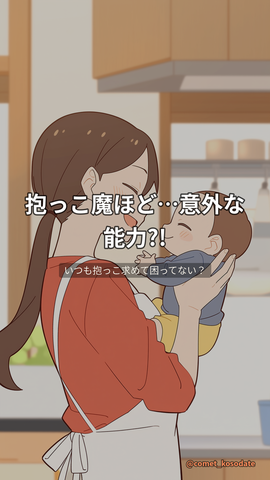

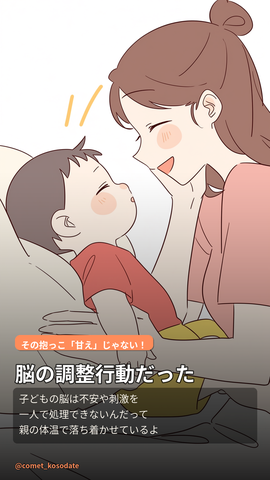

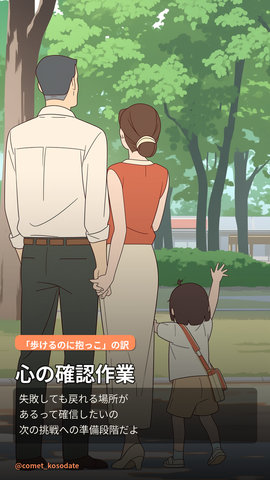

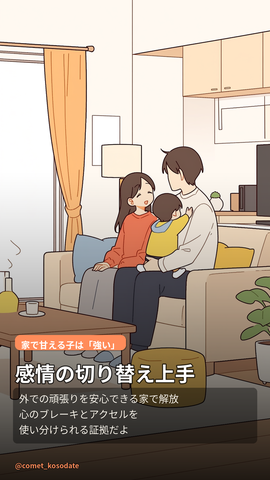

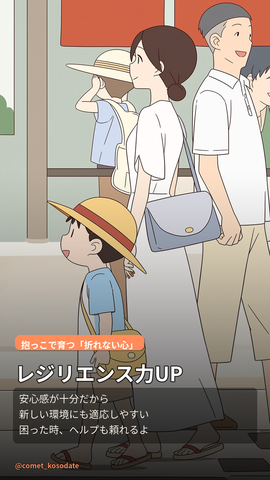

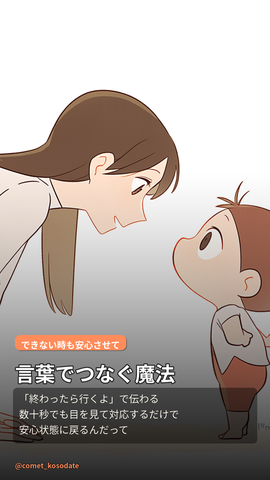

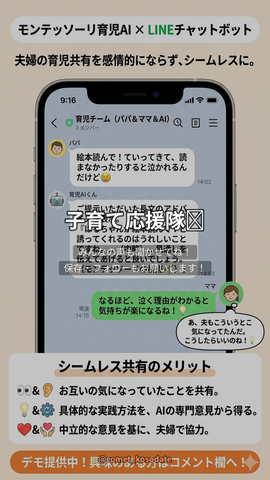

🎤 ナレーション音声: /content/drive/MyDrive/COMET_Reels/20260331_抱っこ魔ほど将来のびる能力/audio

🎬 動画クリップ生成中...
  [1/7] cover...
    🎤 ナレーション付与: scene_01.mp3
  [2/7] content...
    🎤 ナレーション付与: scene_02.mp3
  [3/7] content...
    🎤 ナレーション付与: scene_03.mp3
  [4/7] content...
    🎤 ナレーション付与: scene_04.mp3
  [5/7] content...
    🎤 ナレーション付与: scene_05.mp3
  [6/7] content...
    🎤 ナレーション付与: scene_06.mp3
  [7/7] cta...
    🎤 ナレーション付与: scene_99.mp3
✅ 結合完了（総尺: 34.5秒）
💾 書き出し中: /content/drive/MyDrive/COMET_Reels/20260331_抱っこ魔ほど将来のびる能力/output/reel.mp4

🎉 動画生成完了！
   📹 /content/drive/MyDrive/COMET_Reels/20260331_抱っこ魔ほど将来のびる能力/output/reel.mp4


In [ ]:

import PIL.Image
from IPython.display import display

# structure.json を読み込む（Step 3 を実行していない場合は手動でテーマIDを入力）
try:
    _ = THEME_DIR
except NameError:
    MANUAL_THEME_ID = 'YYYYMMDD_theme_name'  # ← テーマIDを入力
    THEME_DIR  = os.path.join(OUTPUT_DIR, MANUAL_THEME_ID)
    IMAGES_DIR = os.path.join(THEME_DIR, 'images')

OUTPUT_VIDEO = os.path.join(THEME_DIR, 'output', 'reel.mp4')
json_path    = os.path.join(THEME_DIR, 'structure.json')

with open(json_path, 'r', encoding='utf-8') as f:
    structure = json.load(f)

scenes = structure['scenes']
image_paths = []

for i, scene in enumerate(scenes):
    # CTAシーンは固定画像を使用
    if scene.get('type') == 'cta':
        if os.path.exists(CTA_IMAGE_PATH):
            image_paths.append(CTA_IMAGE_PATH)
            print(f'  ✅ CTA固定画像 → シーン{i+1} [cta]  ({os.path.basename(CTA_IMAGE_PATH)})')
        else:
            print(f'  ❌ CTA画像が見つかりません: {CTA_IMAGE_PATH}')
            print('     Step 2 の CTA_IMAGE_PATH を確認してください。')
            raise FileNotFoundError(f'CTA画像が見つかりません: {CTA_IMAGE_PATH}')
        continue

    for ext in ['jpg', 'png', 'jpeg']:
        fpath = os.path.join(IMAGES_DIR, f'{i+1:02d}.{ext}')
        if os.path.exists(fpath):
            image_paths.append(fpath)
            print(f'  ✅ {i+1:02d}.{ext} → シーン{i+1} [{scene["type"]}]')
            break
    else:
        print(f'  ❌ {i+1:02d}.jpg が見つかりません → {IMAGES_DIR} にアップロードしてください')

if len(image_paths) < len(scenes):
    raise FileNotFoundError('画像が不足しています。01〜04.jpg をアップロードしてから再実行してください（CTAは固定画像）。')

print()
print('🖼️ シーンプレビュー...')
for scene, img_path in zip(scenes, image_paths):
    base = add_gradient_overlay(fit_image_to_frame(img_path), scene['type'])
    text = render_text_overlay(scene, scene['type'])
    prev = PIL.Image.alpha_composite(base.convert('RGBA'), text).convert('RGB')
    display(prev.resize((270, 480), PIL.Image.LANCZOS))

# ナレーション音声を読み込み
audio_dir = os.path.join(THEME_DIR, 'audio')
has_audio = os.path.exists(audio_dir)
if has_audio:
    from moviepy.audio.io.AudioFileClip import AudioFileClip
    print(f'🎤 ナレーション音声: {audio_dir}')
else:
    print('⚠️ ナレーション音声なし（Agent 2.5 未実行）')

print()
print('🎬 動画クリップ生成中...')
clips = []
for i, (scene, img_path) in enumerate(zip(scenes, image_paths)):
    print(f'  [{i+1}/{len(scenes)}] {scene["type"]}...')
    dur = scene.get('seconds', 4)
    clip = make_animated_scene(img_path, scene, scene['type'], duration=dur)
    # ナレーション音声があればクリップに付与
    if has_audio:
        audio_path = os.path.join(audio_dir, f"scene_{scene['id']:02d}.mp3")
        if os.path.exists(audio_path):
            audio_clip = AudioFileClip(audio_path)
            clip = clip.set_audio(audio_clip)
            scene_id = scene["id"]
            print(f"    🎤 ナレーション付与: scene_{scene_id:02d}.mp3")
    clips.append(clip)

CROSSFADE = 0.5
faded = [clips[0]] + [c.crossfadein(CROSSFADE) for c in clips[1:]]
final = concatenate_videoclips(faded, padding=-CROSSFADE, method='compose')

print(f'✅ 結合完了（総尺: {final.duration:.1f}秒）')
print(f'💾 書き出し中: {OUTPUT_VIDEO}')

final.write_videofile(OUTPUT_VIDEO, codec='libx264', audio_codec='aac',
                      preset='medium', ffmpeg_params=['-crf', '18'],
                      fps=FPS, verbose=False, logger=None)
final.close()
for c in clips: c.close()

print()
print('=' * 60)
print('🎉 動画生成完了！')
print(f'   📹 {OUTPUT_VIDEO}')
print('=' * 60)


---
## 📊 Agent 3: 分析・改善レポート

投稿後（24〜48時間後）に実行してください。
Instagramアプリのインサイトを見ながら数値を入力すると、Geminiが改善レポートを生成します。

> 📌 回数を重ねるほど「何がバズったか」の精度が上がります。

In [ ]:

def run_agent3():
    print('=' * 60)
    print('📊 Agent 3: 分析・改善エージェント 起動')
    print('=' * 60)

    # 学習データ読み込み
    learnings  = load_learnings()
    learn_text = format_learnings_for_agent(learnings, 'agent3')
    print(f'🧠 {learn_text.splitlines()[0]}')
    print()

    try:
        structure = content_result
        theme_id  = content_result['theme_id']
    except NameError:
        theme_id  = input('分析するテーマID（例: 20250601_night_crying_tips）: ').strip()
        with open(os.path.join(OUTPUT_DIR, theme_id, 'structure.json'), 'r', encoding='utf-8') as f:
            structure = json.load(f)

    AGENT3_SYSTEM = f"""あなたは日本の育児系Instagramアカウント「@comet_kosodate」の分析・改善エージェントです。
投稿パフォーマンスを分析し、次回の具体的な改善アクションを提案します。
過去のデータと比較して、何が効いたか・効かなかったかを論理的に分析してください。

{learn_text}

上記のベンチマークを基準に、今回の数値を評価してください。"""

    print(f'📋 対象: {structure.get("source_topic", {}).get("title", theme_id)}')
    print()
    print('📊 Instagramインサイトを入力してください（アプリの「インサイトを見る」から）:')
    print()

    fields = [
        ('plays',          '再生数（視聴回数）'),
        ('reach',          'リーチ数'),
        ('likes',          'いいね数'),
        ('comments',       'コメント数'),
        ('saves',          '保存数（重要！）'),
        ('shares',         'シェア数'),
        ('profile_visits', 'プロフィールアクセス'),
        ('follows',        'フォロー（この投稿から）'),
    ]

    insights = {}
    for key, label in fields:
        val = input(f'  {label}: ')
        insights[key] = int(val) if val.strip().isdigit() else 0

    if insights['reach'] > 0:
        insights['engagement_rate'] = round((insights['likes'] + insights['comments'] + insights['saves']) / insights['reach'] * 100, 2)
        insights['save_rate']       = round(insights['saves'] / insights['reach'] * 100, 2)
        insights['play_rate']       = round(insights['plays'] / insights['reach'] * 100, 2)
    else:
        insights['engagement_rate'] = insights['save_rate'] = insights['play_rate'] = 0

    print()
    print(f'  → ER: {insights["engagement_rate"]}% / 保存率: {insights["save_rate"]}% / 視聴率: {insights["play_rate"]}%')
    print()
    print('🤖 Geminiが分析 + 学習データ更新中...')

    history = load_history()
    history_summary = '\n'.join([
        f'- {r["theme_id"]}: ER={r["insights"].get("engagement_rate",0)}%, 保存率={r["insights"].get("save_rate",0)}%, フック={r.get("hook_type","-")}'
        for r in history
    ]) if history else '（履歴なし・初回）'

    scene_summary = json.dumps(
        [{'id': s['id'], 'type': s['type'], 'main_text': s.get('main_text', '')} for s in structure['scenes']],
        ensure_ascii=False
    )

    prompt = f"""以下の投稿データを分析してください。

【今回の投稿】
テーマ: {structure.get('source_topic', {}).get('title', theme_id)}
フック型: {structure.get('hook_type', '不明')}
シーン構成: {scene_summary}

【インサイト】
再生数: {insights['plays']:,} / リーチ: {insights['reach']:,}
いいね: {insights['likes']:,} / コメント: {insights['comments']:,}
保存: {insights['saves']:,} / シェア: {insights['shares']:,}
ER: {insights['engagement_rate']}% / 保存率: {insights['save_rate']}% / 視聴率: {insights['play_rate']}%
新規フォロワー: {insights['follows']:,}

【過去の実績】
{history_summary}

{learn_text}

以下のJSON形式で出力してください：
{{
  "overall_score": 75,
  "summary": "総評（100字）",
  "strengths": ["よかった点1", "よかった点2"],
  "weaknesses": ["改善点1", "改善点2"],
  "kpi_analysis": {{
    "plays": "再生数の評価",
    "engagement": "ERの評価",
    "saves": "保存率の評価",
    "follows": "フォロワー転換の評価"
  }},
  "improvements": [
    {{"priority": 1, "category": "カバー/構成/キャプション/ハッシュタグ/投稿時間", "action": "具体的アクション", "reason": "理由"}}
  ],
  "next_topic_suggestion": "次回おすすめネタ",
  "ab_test_idea": "次回ABテスト案",
  "learning_update": {{
    "agent1": {{
      "top_hook_types": ["逆張り", "数字", "疑問形"],
      "top_queries": ["夜泣き 対策", "離乳食 コツ"],
      "avoid_topics": ["反応悪かったトピック傾向"],
      "insights": "Agent1への知見（50字）"
    }},
    "agent2": {{
      "hook_type_scores": {json.dumps(learnings.get('agent2', {}).get('hook_type_scores', {}), ensure_ascii=False)},
      "content_insights": "シーン構成・本文の改善知見（50字）",
      "caption_insights": "キャプションの改善知見（50字）",
      "hashtag_insights": "ハッシュタグの改善知見（50字）",
      "mj_prompt_insights": "MJプロンプトの改善知見（50字）"
    }},
    "agent3": {{
      "benchmarks": "ER・保存率・再生数のベンチマーク更新（50字）",
      "pattern_insights": "バズるコンテンツのパターン知見（50字）"
    }}
  }}
}}"""

    result = extract_json(call_gemini(prompt, AGENT3_SYSTEM, json_mode=True))

    # ── 学習データを更新 ──
    lu = result.pop('learning_update', {})
    if lu:
        new_learnings = dict(learnings)
        new_learnings['total_posts'] = learnings.get('total_posts', 0) + 1

        # Agent 1 更新
        if 'agent1' in lu:
            new_learnings['agent1'].update(lu['agent1'])

        # Agent 2 更新（hook_type_scoresは今回のERで更新）
        if 'agent2' in lu:
            a2 = new_learnings.get('agent2', {})
            a2.update({k: v for k, v in lu['agent2'].items() if k != 'hook_type_scores'})
            # hook_type_scores: 移動平均で更新
            hook_scores = a2.get('hook_type_scores', {})
            hook_type   = structure.get('hook_type', '')
            if hook_type:
                prev = hook_scores.get(hook_type, insights['engagement_rate'])
                hook_scores[hook_type] = round((prev + insights['engagement_rate']) / 2, 2)
            a2['hook_type_scores'] = hook_scores
            new_learnings['agent2'] = a2

        # Agent 3 更新（ベンチマーク移動平均）
        if 'agent3' in lu:
            a3 = new_learnings.get('agent3', {})
            a3.update(lu['agent3'])
            for key, val in [('avg_er', insights['engagement_rate']),
                             ('avg_save_rate', insights['save_rate']),
                             ('avg_plays', insights['plays'])]:
                prev = a3.get(key)
                a3[key] = round((prev + val) / 2, 2) if prev is not None else val
            new_learnings['agent3'] = a3

        update_learnings(new_learnings)

    # ── レポート保存 ──
    today = datetime.datetime.now().strftime('%Y%m%d')
    report_data = {
        'theme_id':    theme_id,
        'analyzed_at': datetime.datetime.now().isoformat(),
        'insights':    insights,
        'hook_type':   structure.get('hook_type', ''),
        'report':      result
    }
    json_path = os.path.join(HISTORY_DIR, f'{today}_{theme_id}_report.json')
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(report_data, f, ensure_ascii=False, indent=2)

    md_lines = [
        f'# 分析レポート: {theme_id}', f'分析日: {today}', '',
        f'## 総合スコア: {result["overall_score"]}/100', '',
        f'### 総評', result['summary'], '',
        '### インサイト',
        f'| 指標 | 数値 |', f'|---|---|',
        f'| ER | {insights["engagement_rate"]}% |',
        f'| 保存率 | {insights["save_rate"]}% |',
        f'| 再生数 | {insights["plays"]:,} |',
        f'| 新規フォロワー | {insights["follows"]:,} |', '',
        '### よかった点', *[f'- {s}' for s in result['strengths']], '',
        '### 改善点', *[f'- {w}' for w in result['weaknesses']], '',
        '### 改善アクション',
        *[f'{i["priority"]}. **[{i["category"]}]** {i["action"]}\n   → {i["reason"]}' for i in result['improvements']], '',
        f'### 次回ネタ提案', result['next_topic_suggestion'], '',
        f'### ABテスト案', result['ab_test_idea'],
    ]
    with open(json_path.replace('.json', '.md'), 'w', encoding='utf-8') as f:
        f.write('\n'.join(md_lines))

    # ── 表示 ──
    print()
    print('=' * 60)
    print(f'📊 分析レポート: {theme_id}')
    print('=' * 60)
    print(f'🏆 総合スコア: {result["overall_score"]}/100')
    print(f'📝 総評: {result["summary"]}')
    print()
    print('✅ よかった点:')
    for s in result['strengths']:  print(f'   • {s}')
    print()
    print('⚠️  改善点:')
    for w in result['weaknesses']: print(f'   • {w}')
    print()
    print('🔧 改善アクション（優先順）:')
    for imp in result['improvements']:
        print(f'   {imp["priority"]}. [{imp["category"]}] {imp["action"]}')
        print(f'      → {imp["reason"]}')
        print()
    print(f'💡 次回ネタ: {result["next_topic_suggestion"]}')
    print(f'🧪 ABテスト: {result["ab_test_idea"]}')
    print()

    # 更新後の学習データサマリーを表示
    updated = load_learnings()
    print('━━━ 🧠 学習データ更新済み ━━━━━━━━━━━━━━━━━━━━━━')
    print(f'  累計投稿数: {updated["total_posts"]}本')
    a2 = updated.get('agent2', {})
    if a2.get('hook_type_scores'):
        sorted_hooks = sorted(a2['hook_type_scores'].items(), key=lambda x: x[1], reverse=True)
        print(f'  フック型ER: {" > ".join([f"{k}({v}%)" for k,v in sorted_hooks])}')
    a3 = updated.get('agent3', {})
    if a3.get('avg_er') is not None:
        print(f'  平均ER: {a3["avg_er"]}% / 保存率: {a3["avg_save_rate"]}%')
    print(f'  次回Agent 1・2・3 起動時に自動反映されます')

    return report_data

def load_history(n=10):
    reports = []
    for fname in sorted(os.listdir(HISTORY_DIR)):
        if fname.endswith('_report.json'):
            with open(os.path.join(HISTORY_DIR, fname), 'r', encoding='utf-8') as f:
                reports.append(json.load(f))
    return reports[-n:]

analysis_report = run_agent3()
